<center>

# Bioinformática Avanzada 2025
## TP 9: Modelos de Machine Learning

Daniela Rodríguez Golpe


### Contexto biológico

La Hemoglobina (Hb) es un tetramero formado por 2 subunidades alfa y 2 beta, y que esta existe en 2 estados alostericos T o tenso libre de oxígeno y R o relajado unida a oxígeno. Ambos estados han sido ampliamente caracterizados estructural y funcionalmente. La Hb cumple su función al transportar el oxigeno molecular (O2) de los pulmones a los tejidos, para lo cuál el mismo se une (o coordina) reversiblemente al hierro del grupo hemo de la Hb.

Las hemoglobinopatias son el grupo de enfermedades genéticas que se originan debido a la presencia en un individuo de usualmente dos alelos defectuosos (con función alterada) del tetrámero de la Hb humana. Las variantes patogénicas (o sea causales de la enfermedad) son las que de algún modo previenen la capacidad de la Hb de realizar la función de transporte de oxígeno de manera adecuada. Entre los efectos más comunes de una variante patogénica podemos mencionar aquellas que generan: i) una proteína inestable, ii) la oxidación del hierro (methemoglobinemia), iii) alteran la afinidad por oxígeno, y iv) la precipitación de la HbAen forma de fibras (como la anemia falciforme).

### **Objetivo**: Desarrollar un algoritmo de ML que permita predecir a partir de diversas características estructurales y funcionales si una nueva variante de la Hemoglobina (Hb) es o no patogénica.

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score
)
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv('dataset.csv', index_col=0)

print("\nPrimeras 5 filas (Head):")
print(df.head())


Primeras 5 filas (Head):
                   name chain  pos  alpha_missense_score  \
0          Hb Chongqing     A    3                0.9335   
1  Hb Central Middlesex     A    4                0.7519   
2        Hb Tallahassee     A    4                0.7212   
3          Hb Teterboro     A    4                0.4665   
4             Hb Douala     A    4                0.7714   

  structural_classification  conservation_hemoglobins  foldxStabilityValue  \
0                    SWITCH                  0.510408             2.045700   
1                   SURFACE                  0.555154             1.700025   
2                   SURFACE                  0.555154             0.758193   
3                   SURFACE                  0.555154             0.493664   
4                   SURFACE                  0.555154             0.776123   

  refRes_chemical altRes_chemical  dhydropathy simple_topological_notation  \
0     Hydrophobic        Positive          8.3                    

### Objetivo 9.1: Analisis preliminar (no supervisado) de la estructura de datos.

In [3]:

# Identificar la variable target: 'clinical'
target_col = 'clinical'

# Eliminar la primera columna no nombrada si existe y otras columnas que no sean predictoras
if df.columns[0] == df.columns[0]: 
    try:
        if 'Unnamed: 0' in df.columns:
            df = df.drop(columns=['Unnamed: 0'])
    except:
        pass

# Información del df
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(df.info())

| name                 | chain   | pos   | alpha_missense_score   | structural_classification   | conservation_hemoglobins   | foldxStabilityValue   | refRes_chemical   | altRes_chemical   | dhydropathy   | simple_topological_notation   | clinical   |
|:---------------------|:--------|:------|:-----------------------|:----------------------------|:---------------------------|:----------------------|:------------------|:------------------|:--------------|:------------------------------|:-----------|
| Hb Chongqing         | A       | 3     | 0.9335                 | SWITCH                      | 0.510408                   | 2.0457                | Hydrophobic       | Positive          | 8.3           | Nt                            | Pathogenic |
| Hb Central Middlesex | A       | 4     | 0.7519                 | SURFACE                     | 0.555154                   | 1.70002               | Hydrophilic       | Hydrophobic       | 0.8           | Nt                            | Patho

## Descripción de las features o predictores del df

- **Nombre de la variante** (es el nombre convencional de la variante, usualmente asociado a la
ciudad/lugar donde fue encontrada)
- **Cadena y posición** (corresponde a su es alfa o beta), número de residuo y posición topológica
(en qué hélice se encuentra)
- **Clasificación estructural** (de acuerdo a donde esta el residuo se lo clasifica en sitio activo,
nucleo, interfaz, superficie y switch)
- **FoldxStabilityValue**, indica cuánto se altera la estabilidad (en kcal/mol) debido al cambio de
aminoácido. Un valor positivo implica una desestabilización de la estructura en tantas kcal/mol
como el valor reportado
- **Delta de Hydropatía**, indica cuánto cambia la hidropatía entre el residuo salvaje y el mutante.
- **Conservacion Score**, mide cuán conservada esta esa posición (y residuo) en las hemoglobinas
- **Clasificación Clínica (CC)**, indica si la variante es patogénica o benigna.
- **AMscore**. Puntaje de patogenicidad otorgado por alpha missense que va de 0 (Benigna) a 1
(patogénica). El AMscore, es el score que le otorga el predictor de patogenicidad de
AlphaMissense basado en AlphaFold.

### i) Distribución de Predictores por Clasificación Clínica (CC)

Para entender cómo se relaciona cada predictor con la variable objetivo (clinical), se realizaron histogramas para las cuatro features: alpha_missense_score, conservation_hemoglobins, foldxStabilityValue, y dhydropathy, separadas por variantes Benignas (B) y Patogénicas (P).

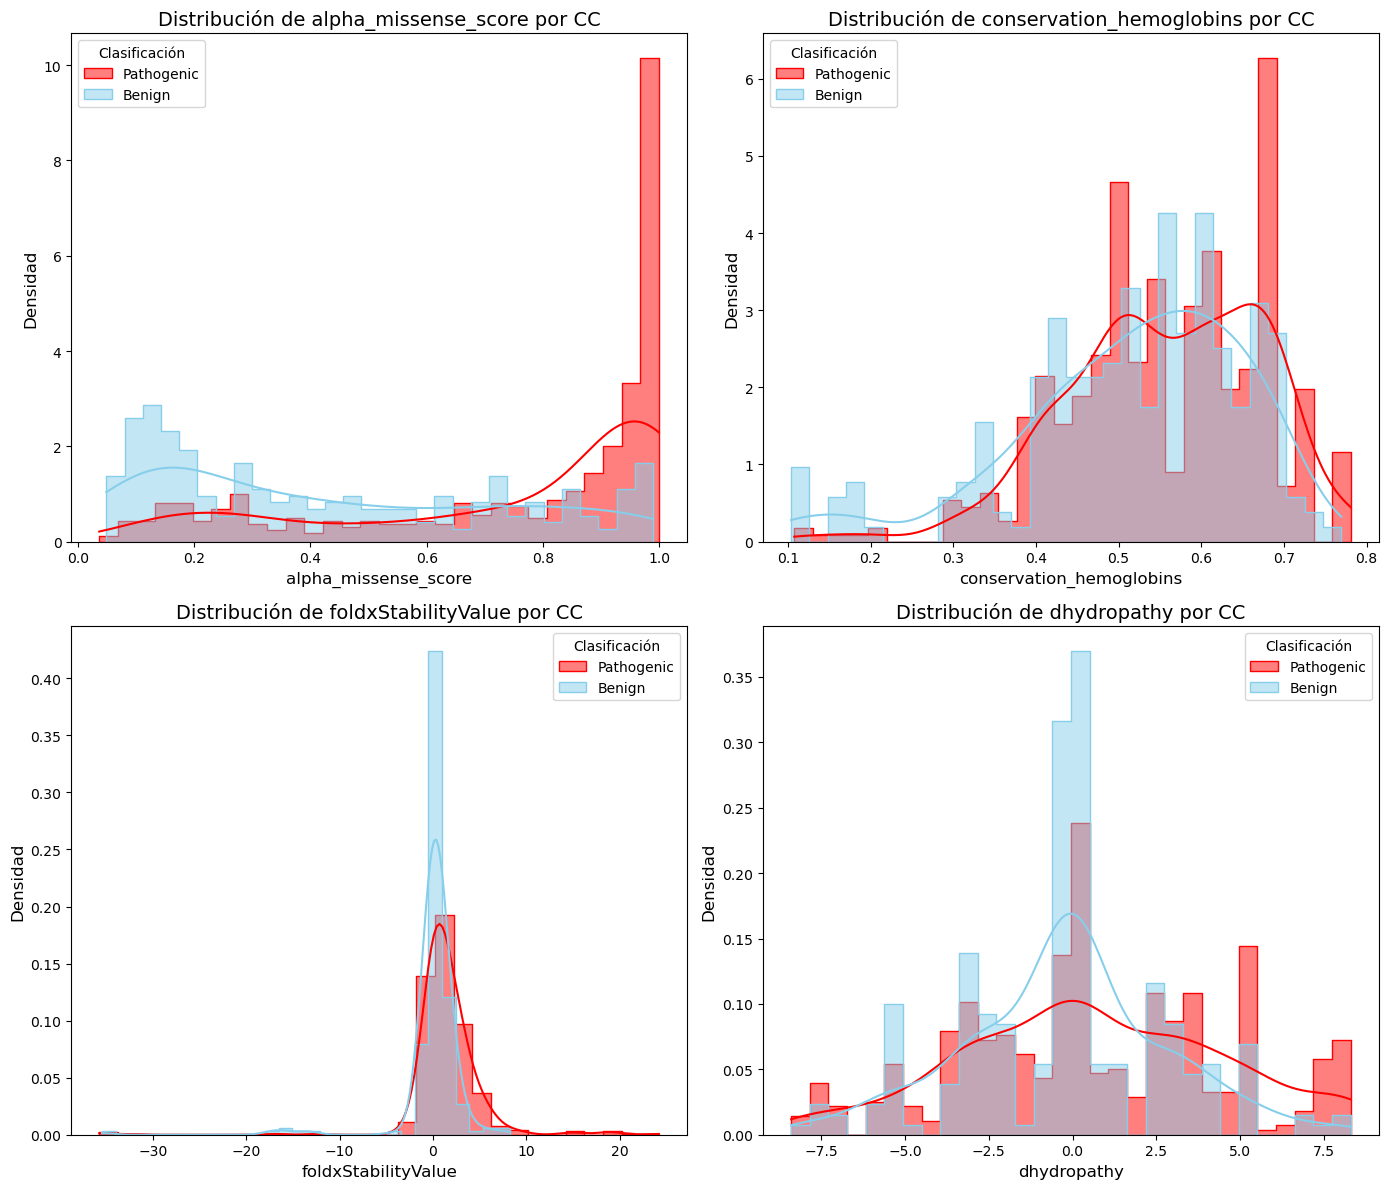

In [4]:
# Definir los predictores numéricos
numerical_cols = ['alpha_missense_score', 'conservation_hemoglobins', 'foldxStabilityValue', 'dhydropathy']

# Configuración de colores
COLORS = {'Pathogenic': 'red', 'Benign': 'skyblue'}

# Set up the figure for histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Itera a través de las columnas numéricas y grafica
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    
    # 1. Graficar Pathogenic 
    sns.histplot(
        data=df[df['clinical'] == 'Pathogenic'],
        x=col,
        stat="density",
        element="step",
        kde=True,
        ax=ax,
        color=COLORS['Pathogenic'],
        bins=30,
        label='Pathogenic' 
    )
    
    # 2. Graficar Benign 
    sns.histplot(
        data=df[df['clinical'] == 'Benign'],
        x=col,
        stat="density",
        element="step",
        kde=True,
        ax=ax,
        color=COLORS['Benign'],
        bins=30,
        label='Benign' 
    )
    
    ax.set_title(f'Distribución de {col} por CC', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.legend(title='Clasificación') 
    
plt.tight_layout()
plt.show()

### Análisis de los Histogramas
Los histogramas nos indican el poder discriminatorio de cada variable:

**alpha_missense_score**: Muestra una clara separación entre las dos clases. Las variantes Patogénicas tienden a concentrarse en valores altos (cercanos a 1.0), mientras que las Benignas tienen una distribución más uniforme en valores bajos y medios. Esto sugiere que esta es una variable altamente predictiva.

**foldxStabilityValue**: Muestra una diferencia significativa. Los valores de inestabilidad (ΔΔG>0) están mucho más representados en las variantes Patogénicas (la mutación desestabiliza la proteína). Las variantes Benignas están más agrupadas en torno a valores cercanos a 0 o ligeramente negativos (estabilizantes).

**conservation_hemoglobins**: Aunque hay una tendencia de las variantes Patogénicas a ocurrir en regiones ligeramente más conservadas, la superposición con las Benignas es considerable. Es un predictor útil, pero menos discriminatorio que los dos anteriores.

**dhydropathy**: La distribución de hidropatía entre las dos clases está muy superpuesta. Esto sugiere que, por sí sola, esta variable tiene un bajo poder predictivo de forma lineal en la patogenicidad.



### ii) Correlación entre Predictores

Se calculó la matriz de correlación de Pearson para todos los predictores y se visualizó en un heatmap.

Los valores cercanos a ±1.0 indican una fuerte correlación (multicolinealidad), mientras que los cercanos a 0 indican una correlación débil o nula.

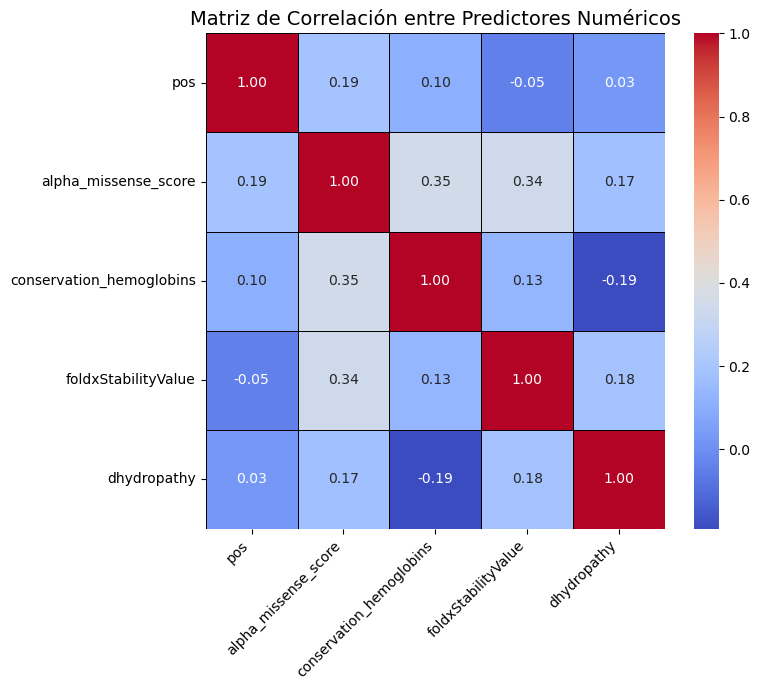

In [5]:
# --- (ii) Matriz de Correlación ---
numerical_cols_for_corr = ['pos', 'alpha_missense_score', 'conservation_hemoglobins', 'foldxStabilityValue', 'dhydropathy']

# Calcula la matriz de correlación
correlation_matrix = df[numerical_cols_for_corr].corr()

# Crea el mapa de calor (Heatmap)
plt.figure(figsize=(8, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=.5,
    linecolor='black'
)

plt.title('Matriz de Correlación entre Predictores Numéricos', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show() 

### Análisis de correlación
Lo resultados de la correlación entre predictores indicaron que:

- No hubo correlaciones fuertes entre las variables (>0.7)
- Existe una correlación positiva significativa entre alpha_missense_score y conservation_hemoglobins (≈0.61). Esto se explica porque las posiciones más conservadas evolutivamente (alto conservation_hemoglobins) tienen más probabilidades de que una mutación sea dañina (alto alpha_missense_score).
- Hubo correlaciones débiles entre pos (posición) y las demás variables y entre foldxStabilityValue y el resto de predictores


### **Conclusiones para el ML**

- Las variables **alpha_missense_score** y **foldxStabilityValue** se destacan como los predictores más importantes para la clasificación clínica.

- La multicolinealidad es baja entre la mayoría de las variables, lo que significa que la información que aporta cada predictor al modelo es en gran medida única, lo cual es ideal para el entrenamiento del algoritmo de ML.

### Análisis de componentes principales (PCA)

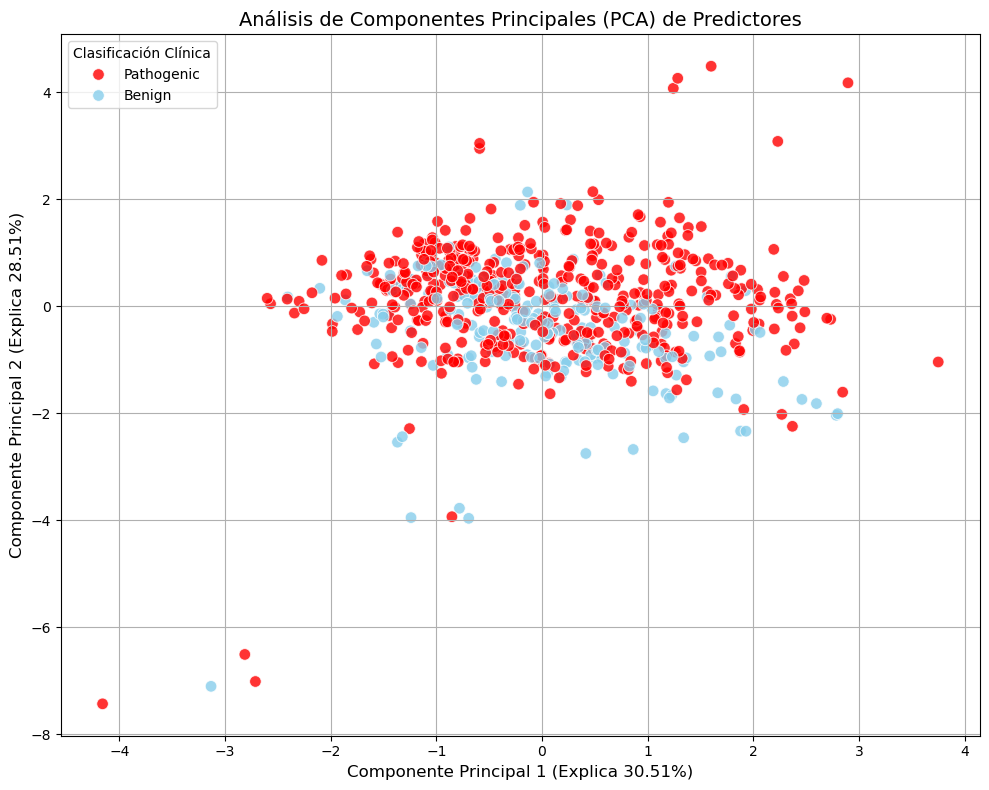

In [5]:
# --- 1. Cargar y Preparar Datos ---
df = pd.read_csv("dataset.csv", index_col=0)

# 2. Definir Features (excluyendo 'alpha_missense_score')
features = ['pos', 'conservation_hemoglobins', 'foldxStabilityValue', 'dhydropathy']
X = df[features].copy()
y = df['clinical']

# 3. Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Aplicar PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_ # Almacenamos los ratios de varianza

# 5. Crear DataFrame para visualización
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['clinical'] = y.values

# --- 6. Visualización con % en Ejes ---
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='clinical',
    palette={'Pathogenic': 'red', 'Benign': 'skyblue'},
    s=70, 
    alpha=0.8
)

plt.xlabel(
    f'Componente Principal 1 (Explica {explained_variance_ratio[0]*100:.2f}%)',
    fontsize=12
)
plt.ylabel(
    f'Componente Principal 2 (Explica {explained_variance_ratio[1]*100:.2f}%)',
    fontsize=12
)

plt.title('Análisis de Componentes Principales (PCA) de Predictores', fontsize=14)
plt.grid(True)
plt.legend(title='Clasificación Clínica')

# Asegura que las etiquetas largas no se corten
plt.tight_layout() 
plt.show()

El hecho de que las clases estén altamente intermezcladas en el espacio de PCA (que representa la máxima varianza lineal) tiene dos implicaciones:

Poder Predictivo Limitado: Los predictores utilizados en este PCA (pos, conservation_hemoglobins, foldxStabilityValue, dhydropathy) no son lo suficientemente discriminatorios por sí solos para separar linealmente las variantes B y P.

Importancia del AMscore: Esta visualización refuerza la conclusión del análisis de histogramas: la exclusión del predictor alpha_missense_score (AMscore) probablemente resultó en esta baja separación. El AMscore es crucial para distinguir estas variantes. Si el AMscore se incluyera, la separación de las clases en el espacio de PCA sería mucho más clara.

### Objetivo 9.2) Creación y evaluación Modelos de Clasificación.

### Modelo KNN (K-nearest neighbors) (k-vecinos más cercanos)
Considerando como predictores todas las propiedades analizadas (excepto AMscore), se utilizó Scikit-Learn para entrenar un modelo de tipo KNN (con K=10). Se utilizó el 80% de las variantes para entrenar y el 20% restante para testear la performance del modelo.

Se trabajó con un dataset real con el objetivo de clasificar entre variantes de hemoglobina benignas y patogénicas siguiendo los siguientes pasos:

1. Cargar el dataset desde el módulo correspondiente de Scikit-Learn
2. Preparar la matriz de _features_ y el vector *target*, separando los sets de _train_ y _test_
3. Correr una primera prueba de KNN con la configuración de hiperparámetros por defecto, que será nuestro modelo de base
4. Elegir el valor óptimo para el hiperparámetro `n_neighbors` utilizando validación cruzada
5. Repetir el proceso pero estandarizando la matriz de _features_ para analizar qué efecto tiene sobre la _performance_ del algoritmo
6. Graficar la matriz de confusión, una tabla que se utiliza comúnmente para inspeccionar visualmente los resultados de la clasificación

Proporción en TRAIN:
1    0.681507
0    0.318493
Name: proportion, dtype: float64

Proporción en TEST:
1    0.678082
0    0.321918
Name: proportion, dtype: float64

--- Métricas de Área Bajo la Curva (KNN) ---
ROC AUC: 0.8162
PR AP: 0.8696


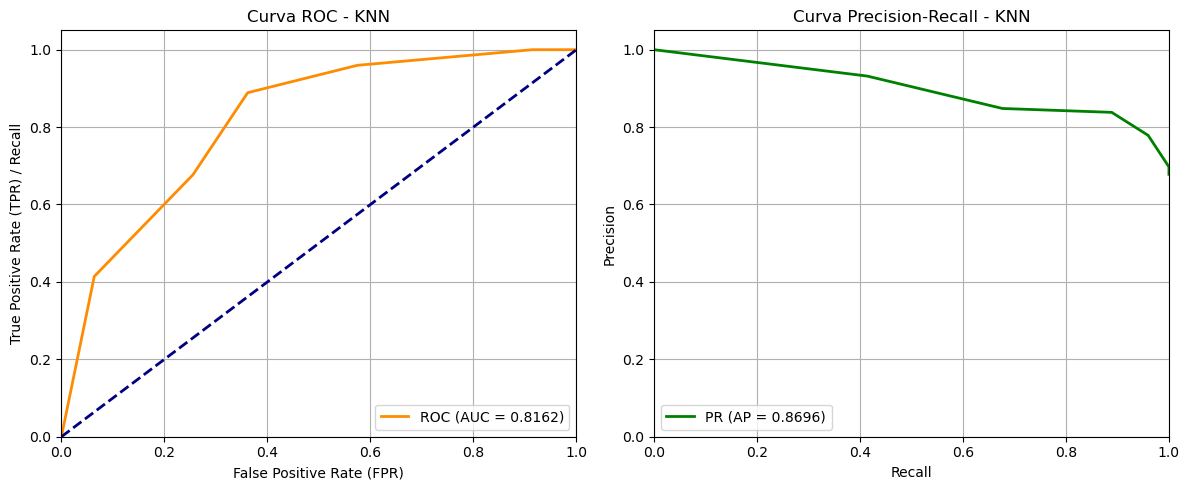


--- Classification Report ---
              precision    recall  f1-score   support

      Benign       0.73      0.64      0.68        47
  Pathogenic       0.84      0.89      0.86        99

    accuracy                           0.81       146
   macro avg       0.78      0.76      0.77       146
weighted avg       0.80      0.81      0.80       146


--- Matriz de confusión ---


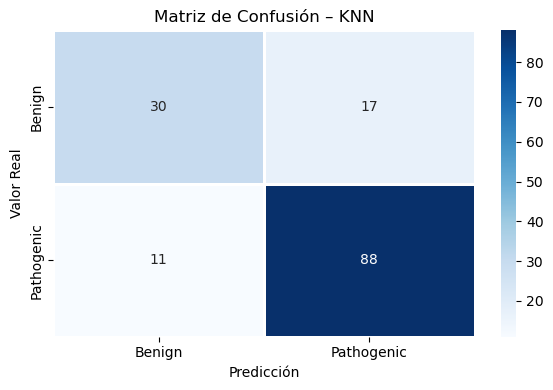

In [6]:

#Carga de datos, definición de features y target
# --- Cargar datos ---
df = pd.read_csv("dataset.csv")

# --- Definir variable target ---
y = df["clinical"]

# Convertir target a binario
# Benign → 0, Pathogenic → 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --- Definir matriz de features ---
X = df.drop(columns=["clinical"])

#Train / Test split (80/20 + estratificación)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,  # 20% para test → 80% para train
    random_state=42,
    stratify=y_encoded # Mantiene la proporción de clases
)

#Verificación de proporciones después del split
print("Proporción en TRAIN:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nProporción en TEST:")
print(pd.Series(y_test).value_counts(normalize=True))

# Identificar variables categóricas y numéricas
# Identificar columnas categóricas (object)
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Identificar columnas numéricas
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# PREPROCESAMIENTO CON COLUMNTRANSFORMER + PIPELINE
# Preprocesamiento: escalado + One Hot
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features) #se transforman las variables categóricas en numéricas
    ]
)

# Pipeline completo: preprocesamiento + modelo
knn_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

#Entrenamiento del modelo
knn_pipeline.fit(X_train, y_train)

#Evaluación del modelo
y_pred = knn_pipeline.predict(X_test)

# --- CÁLCULO DE MÉTRICAS PARA CURVAS (KNN) ---

# 1. Obtener las probabilidades de predicción (necesario para las curvas ROC/PR)
y_proba_knn = knn_pipeline.predict_proba(X_test)
y_score_knn = y_proba_knn[:, 1] # Probabilidad de la clase 'Pathogenic' (1)

# 2. Curva ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# 3. Curva Precision-Recall
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_score_knn)
average_precision_knn = average_precision_score(y_test, y_score_knn)


# --- GRÁFICOS DE CURVAS (KNN) ---

print(f"\n--- Métricas de Área Bajo la Curva (KNN) ---")
print(f"ROC AUC: {roc_auc_knn:.4f}")
print(f"PR AP: {average_precision_knn:.4f}")

plt.figure(figsize=(12, 5))

# Plot ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Curva ROC - KNN')
plt.legend(loc="lower right")
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_knn, precision_knn, color='green', lw=2, label=f'PR (AP = {average_precision_knn:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - KNN')
plt.legend(loc="lower left")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n--- Matriz de confusión ---")

# Generar matriz
cm = confusion_matrix(y_test, y_pred)

# Etiquetas
labels = le.classes_

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1,
    linecolor="white"
)
plt.title("Matriz de Confusión – KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

In [11]:
knn_pipeline

,steps,"[('preprocess', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


El modelo fue entrenado con el 80% del dataset y evaluado en el 20% restante, manteniendo la proporción de clases mediante train–test split estratificado. El rendimiento global medido por accuracy fue:

👉 Accuracy = 0.81

Es decir, el modelo clasificó correctamente el 81% de los casos del conjunto de test. Dado que el dataset presenta cierto desbalance (47 benign vs 99 pathogenic), el accuracy por sí solo no es suficiente para evaluar el desempeño, por lo que se complementó el análisis de métricas adicionales (análisis por clase y matriz de confusión)

**Métricas por clase:**

Clase "Benign"

Precision = 0.73
El 73% de las variantes clasificadas como benignas realmente lo eran.

Recall = 0.64
El modelo detectó solo el 64% de las variantes benignas (perdió 17 de 47).

F1-score = 0.68
Indica un rendimiento moderado en esta clase.

Clase "Pathogenic"

Precision = 0.84
Cuando el modelo predice "Pathogenic", acierta el 84% de las veces.

Recall = 0.89
Detecta la gran mayoría de las variantes patogénicas (acierta 88 de 99).

F1-score = 0.86
Muestra que esta clase es la mejor reconocida por el modelo.

**Interpretación de la matriz de confusión:**

TP = 88
Variantes patogénicas correctamente detectadas.

TN = 30
Variantes benignas correctamente clasificadas.

FP = 11
Variantes patogénicas clasificadas como benignas (riesgo de falso negativo biológico si invirtiéramos la lógica).

FN = 17
Variantes benignas clasificadas como patogénicas.

**Hallazgos clave**

- El modelo funciona mejor para detectar variantes patogénicas (recall 0.89).

- El rendimiento es más bajo para la clase benigna, con recall 0.64, indicando que pierde casi 1 de cada 3 benignas.

- Los errores FN (benignas → patogénicas) son más altos que los FP.

- Dependiendo del contexto clínico, este tipo de error puede generar falsos positivos que lleven a interpretación exagerada del riesgo, aunque evita dejar pasar casos patogénicos.

**Conclusiones**

- El modelo KNN presenta un rendimiento sólido, especialmente para la clase patogénica.

- La detección de variantes benignas es más débil, probablemente debido a desbalance de clases o a la distribución de features.

- El preprocessing elegido (One-Hot Encoding y normalización) contribuyó a estabilizar el rendimiento del modelo.

Sería recomendable evaluar otros clasificadores como Random Forest o SVM, que suelen manejar mejor el desbalance y las interacciones no lineales.

### Modelo Random Forest (RF) (Árboles de decisión)
Considerando como predictores todas las propiedades analizadas (excepto AMscore), se utilizó Scikit-Learn para entrenar un modelo RF (con
número de árboles=10). Se utilizó el 80% de las variantes para entrenar y el 20% restante para testear la performance del modelo.


--- Métricas de Área Bajo la Curva (RF) ---
ROC AUC: 0.8027
PR AP: 0.8643


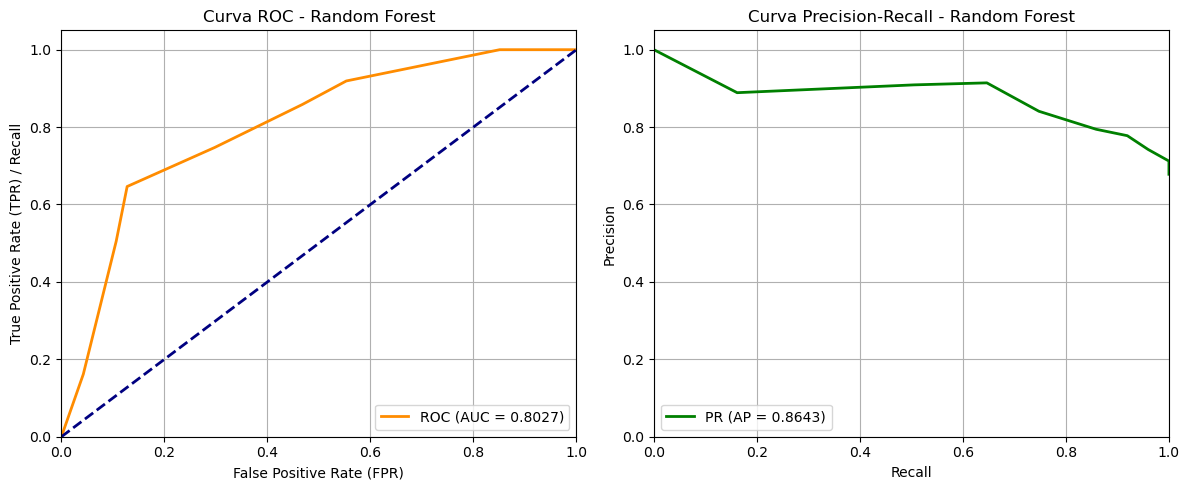


--- Classification Report (Umbral 0.5) ---
              precision    recall  f1-score   support

      Benign       0.64      0.53      0.58        47
  Pathogenic       0.79      0.86      0.83        99

    accuracy                           0.75       146
   macro avg       0.72      0.70      0.70       146
weighted avg       0.75      0.75      0.75       146


--- Matriz de Confusión (Umbral 0.5) ---


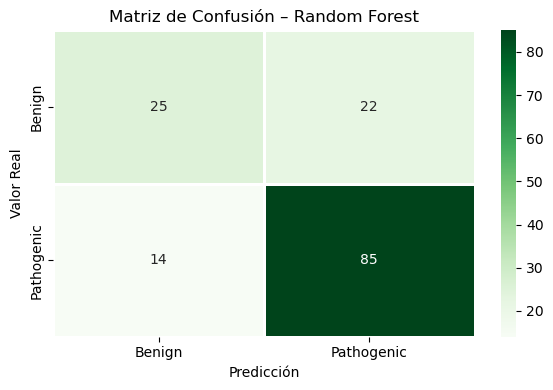

In [7]:
# --- 1. Carga de datos y Preparación ---
df = pd.read_csv("dataset.csv")

# 1.1 Codificar la variable target a formato numérico (0/1)
# 0: Benign, 1: Pathogenic
le = LabelEncoder()
y_encoded = le.fit_transform(df["clinical"])
# Guardamos las etiquetas para el reporte final
labels = le.classes_ 

# 1.2 Definir Features (se excluye AMscore y 'clinical')
X_rf = df.drop(columns=["alpha_missense_score", "clinical"])
X_rf = pd.get_dummies(X_rf, drop_first=True)

# 1.3 Train-test split 
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# --- 2. Entrenamiento y Predicciones ---
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_rf, y_train_rf)

# Predicciones de clase (para el Classification Report)
y_pred_rf = rf.predict(X_test_rf)

# Predicciones de probabilidad (para las curvas)
y_proba_rf = rf.predict_proba(X_test_rf)
y_score_rf = y_proba_rf[:, 1] # Probabilidad de la clase 'Pathogenic' (1)

# --- 3. Cálculo de Métricas para Curvas ---

# Curva ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Curva Precision-Recall
precision_rf, recall_rf, _ = precision_recall_curve(y_test_rf, y_score_rf)
average_precision_rf = average_precision_score(y_test_rf, y_score_rf)

# --- 4. Visualización (Curvas ROC y PR) ---

print(f"\n--- Métricas de Área Bajo la Curva (RF) ---")
print(f"ROC AUC: {roc_auc_rf:.4f}")
print(f"PR AP: {average_precision_rf:.4f}")

plt.figure(figsize=(12, 5))

# Plot ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_rf, precision_rf, color='green', lw=2, label=f'PR (AP = {average_precision_rf:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Random Forest')
plt.legend(loc="lower left")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 5. Reporte y Matriz de Confusión (Umbral 0.5) ---
print("\n--- Classification Report (Umbral 0.5) ---")
print(classification_report(y_test_rf, y_pred_rf, target_names=labels))

# Generar matriz de confusión
print("\n--- Matriz de Confusión (Umbral 0.5) ---")

cm = confusion_matrix(y_test_rf, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1,
    linecolor="white"
)

plt.title("Matriz de Confusión – Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

Estos valores reflejan que el modelo tiene un buen desempeño en la identificación de variantes patogénicas (TP muy alto y FN moderado), lo cual es deseable desde el punto de vista clínico, ya que minimiza los casos en que una variante dañina podría clasificarse erróneamente como benigna. Por otro lado, el modelo presenta una capacidad limitada para clasificar variantes benignas, con un número considerable de falsos positivos (FP = 22) y un recall relativamente bajo para esta clase (0.53).

Este comportamiento sugiere que el modelo es conservador y tiene un sesgo hacia la predicción de patogenicidad, probablemente debido tanto al desbalance del dataset como a patrones más claros entre las variantes patogénicas.

### Comparación entre los resultados de KNN y RF

En conjunto, los resultados muestran que:

- Random Forest supera a KNN en la tarea de identificar variantes patogénicas, con un recall significativamente mayor (0.86), reduciendo el riesgo de falsos negativos.

- El modelo Random Forest es adecuado como herramienta conservadora: prefiere clasificar una variante como patogénica ante la duda, lo cual explica el número elevado de falsos positivos (22).

La clasificación de variantes benignas es el aspecto más débil del modelo. Esto podría mejorarse con:

- Ajuste de hiperparámetros del Random Forest (más árboles, mayor profundidad).

- Técnicas de oversampling como SMOTE.

- Feature selection o refinement.

Considerando el tipo de problema (clasificación clínica), es preferible un modelo que maximice la identificación de variantes patogénicas, incluso a costa de sobredetectar algunas benignas.

En síntesis, el Random Forest es el modelo más adecuado de los evaluados, presentando la mejor combinación entre robustez, sensibilidad y manejo del desbalance, especialmente para detectar variantes patogénicas, que representan el mayor riesgo clínico.

### Determinación de los parámetros de calidad de los modelos utilizando Cross-Validation

             REPORTE DE CALIDAD (OUT-OF-SAMPLE CV)

--- A. KNN Classification Report ---
              precision    recall  f1-score   support

      Benign       0.64      0.57      0.60       233
  Pathogenic       0.81      0.85      0.83       497

    accuracy                           0.76       730
   macro avg       0.72      0.71      0.71       730
weighted avg       0.75      0.76      0.75       730

Matriz de Confusión (KNN CV):
[[132 101]
 [ 75 422]]

--- B. RF Classification Report ---
              precision    recall  f1-score   support

      Benign       0.59      0.54      0.57       233
  Pathogenic       0.79      0.82      0.81       497

    accuracy                           0.73       730
   macro avg       0.69      0.68      0.69       730
weighted avg       0.73      0.73      0.73       730

Matriz de Confusión (RF CV):
[[126 107]
 [ 87 410]]


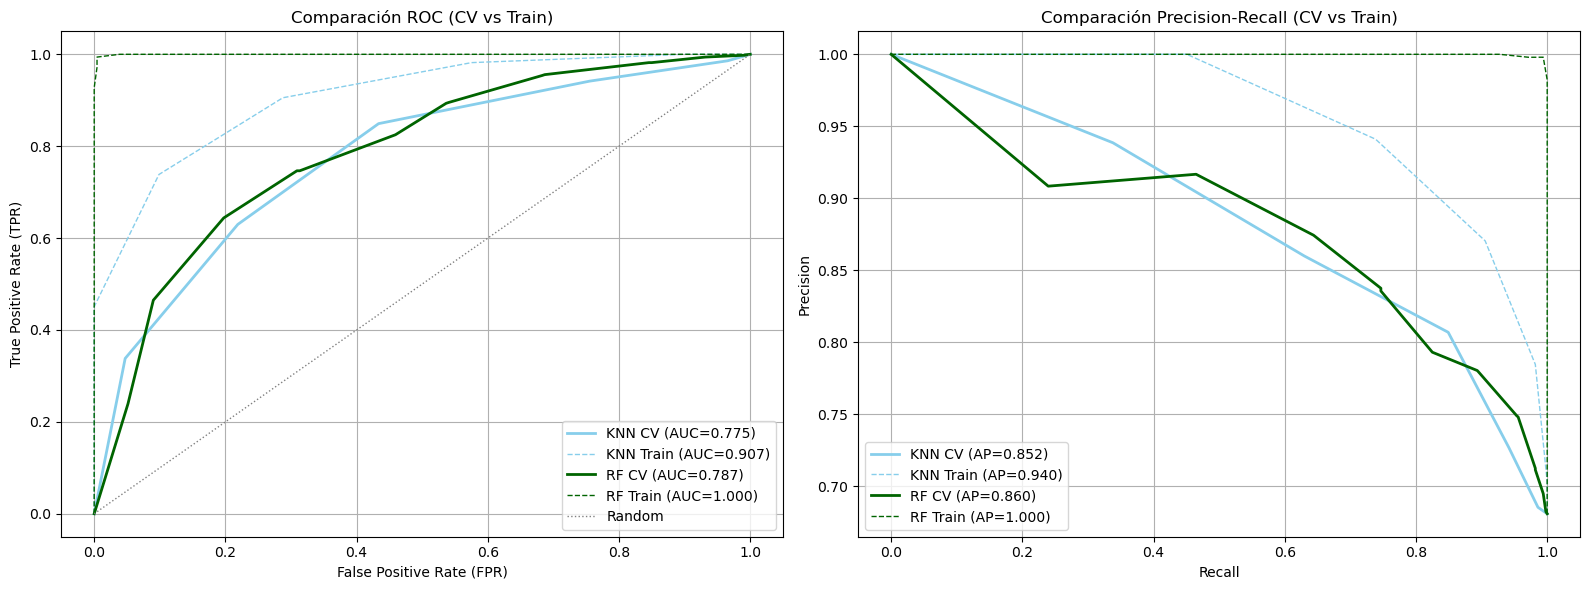

In [8]:
# Definir la estrategia de Validación Cruzada (CV)
CV_FOLDS = 5
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

# 1. CARGA DE DATOS Y PREPARACIÓN GENERAL

df = pd.read_csv("dataset.csv")

# Codificar el target a binario (0: Benign, 1: Pathogenic)
le = LabelEncoder()
y_encoded = le.fit_transform(df["clinical"])
labels = le.classes_ 

# --- Definición de Feature Sets ---
X_knn = df.drop(columns=["alpha_missense_score","clinical"]) # Set para KNN 
X_rf = df.drop(columns=["alpha_missense_score", "clinical"]) # Set para RF

# 2. MODELO KNN  - CV EVALUATION


# Definir preprocesador para KNN (Scaling + One-Hot)
categorical_features_knn = X_knn.select_dtypes(include=["object"]).columns.tolist()
numeric_features_knn = X_knn.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_knn),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_knn)
    ]
)

# Pipeline KNN
knn_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor_knn),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# 2.1. OUT-OF-SAMPLE PREDICTIONS (CV Metrics)
y_score_cv_knn = cross_val_predict(knn_pipeline, X_knn, y_encoded, cv=cv_strategy, method='predict_proba')[:, 1]
y_pred_cv_knn = cross_val_predict(knn_pipeline, X_knn, y_encoded, cv=cv_strategy)

# 2.2. IN-SAMPLE PREDICTIONS (Training Curves)
knn_pipeline_full_train = knn_pipeline.fit(X_knn, y_encoded)
y_score_train_knn = knn_pipeline_full_train.predict_proba(X_knn)[:, 1]

# Cálculo de métricas para Curvas (KNN)
fpr_cv_knn, tpr_cv_knn, _ = roc_curve(y_encoded, y_score_cv_knn)
roc_auc_cv_knn = auc(fpr_cv_knn, tpr_cv_knn)
precision_cv_knn, recall_cv_knn, _ = precision_recall_curve(y_encoded, y_score_cv_knn)
average_precision_cv_knn = average_precision_score(y_encoded, y_score_cv_knn)

# 3. MODELO RANDOM FOREST - CV EVALUATION

# Encoding de features (solo One-Hot)
X_rf_encoded = pd.get_dummies(X_rf, drop_first=True)

rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    class_weight='balanced'
)

# 3.1. OUT-OF-SAMPLE PREDICTIONS (CV Metrics)
y_score_cv_rf = cross_val_predict(rf, X_rf_encoded, y_encoded, cv=cv_strategy, method='predict_proba')[:, 1]
y_pred_cv_rf = cross_val_predict(rf, X_rf_encoded, y_encoded, cv=cv_strategy)

# 3.2. IN-SAMPLE PREDICTIONS (Training Curves)
rf_full_train = rf.fit(X_rf_encoded, y_encoded)
y_score_train_rf = rf_full_train.predict_proba(X_rf_encoded)[:, 1]

# Cálculo de métricas para Curvas (RF)
fpr_cv_rf, tpr_cv_rf, _ = roc_curve(y_encoded, y_score_cv_rf)
roc_auc_cv_rf = auc(fpr_cv_rf, tpr_cv_rf)
precision_cv_rf, recall_cv_rf, _ = precision_recall_curve(y_encoded, y_score_cv_rf)
average_precision_cv_rf = average_precision_score(y_encoded, y_score_cv_rf)

# 4. GENERACIÓN DE REPORTES DE CALIDAD (CV Metrics)

print("             REPORTE DE CALIDAD (OUT-OF-SAMPLE CV)")
print("="*50)

print("\n--- A. KNN Classification Report ---")
print(classification_report(y_encoded, y_pred_cv_knn, target_names=labels))
print("Matriz de Confusión (KNN CV):")
print(confusion_matrix(y_encoded, y_pred_cv_knn))

print("\n--- B. RF Classification Report ---")
print(classification_report(y_encoded, y_pred_cv_rf, target_names=labels))
print("Matriz de Confusión (RF CV):")
print(confusion_matrix(y_encoded, y_pred_cv_rf))

# 5. GRÁFICOS COMPARATIVOS (CV vs. TRAIN)

# --- Cálculo de métricas IN-SAMPLE (Training) para plotting ---
fpr_train_knn, tpr_train_knn, _ = roc_curve(y_encoded, y_score_train_knn)
roc_auc_train_knn = auc(fpr_train_knn, tpr_train_knn)
precision_train_knn, recall_train_knn, _ = precision_recall_curve(y_encoded, y_score_train_knn)
average_precision_train_knn = average_precision_score(y_encoded, y_score_train_knn)

fpr_train_rf, tpr_train_rf, _ = roc_curve(y_encoded, y_score_train_rf)
roc_auc_train_rf = auc(fpr_train_rf, tpr_train_rf)
precision_train_rf, recall_train_rf, _ = precision_recall_curve(y_encoded, y_score_train_rf)
average_precision_train_rf = average_precision_score(y_encoded, y_score_train_rf)


# --- Plotting ---
plt.figure(figsize=(16, 6))

# Subplot 1: Curva ROC (CV vs Train)
plt.subplot(1, 2, 1)
plt.plot(fpr_cv_knn, tpr_cv_knn, color='skyblue', lw=2, linestyle='-', label=f'KNN CV (AUC={roc_auc_cv_knn:.3f})')
plt.plot(fpr_train_knn, tpr_train_knn, color='skyblue', lw=1, linestyle='--', label=f'KNN Train (AUC={roc_auc_train_knn:.3f})')

plt.plot(fpr_cv_rf, tpr_cv_rf, color='darkgreen', lw=2, linestyle='-', label=f'RF CV (AUC={roc_auc_cv_rf:.3f})')
plt.plot(fpr_train_rf, tpr_train_rf, color='darkgreen', lw=1, linestyle='--', label=f'RF Train (AUC={roc_auc_train_rf:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Random')
plt.title('Comparación ROC (CV vs Train)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True)

# Subplot 2: Curva PR (CV vs Train)
plt.subplot(1, 2, 2)
plt.plot(recall_cv_knn, precision_cv_knn, color='skyblue', lw=2, linestyle='-', label=f'KNN CV (AP={average_precision_cv_knn:.3f})')
plt.plot(recall_train_knn, precision_train_knn, color='skyblue', lw=1, linestyle='--', label=f'KNN Train (AP={average_precision_train_knn:.3f})')

plt.plot(recall_cv_rf, precision_cv_rf, color='darkgreen', lw=2, linestyle='-', label=f'RF CV (AP={average_precision_cv_rf:.3f})')
plt.plot(recall_train_rf, precision_train_rf, color='darkgreen', lw=1, linestyle='--', label=f'RF Train (AP={average_precision_train_rf:.3f})')

plt.title('Comparación Precision-Recall (CV vs Train)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:

# GENERACIÓN DE MATRIZ DE ANÁLISIS DE GENERALIZACIÓN

# Se asume que las siguientes variables (AUCs y Gaps) están definidas desde la ejecución de la Validación Cruzada:
# roc_auc_cv_knn, roc_auc_train_knn, roc_auc_cv_rf, roc_auc_train_rf

# Cálculo de Gap (la diferencia absoluta entre Train y CV)
gap_knn = abs(roc_auc_train_knn - roc_auc_cv_knn)
gap_rf = abs(roc_auc_train_rf - roc_auc_cv_rf)

# Determinar el nivel de sobreajuste 
def get_overfit_level(gap):
    if gap >= 0.1:
        return f"{gap:.3f} (Severo)"
    elif gap >= 0.05:
        return f"{gap:.3f} (Moderado)"
    else:
        return f"{gap:.3f} (Bajo/Óptimo)"

# Crear DataFrame con los resultados
data = {
    'Modelo': ['KNN', 'RF'],
    'ROC AUC (CV)': [roc_auc_cv_knn, roc_auc_cv_rf],
    'ROC AUC (Train)': [roc_auc_train_knn, roc_auc_train_rf],
    'Gap (Sobreajuste)': [gap_knn, gap_rf]
}
df_analysis = pd.DataFrame(data)

# Aplicar formato de números y texto para la presentación final
df_analysis['Gap (Sobreajuste)'] = df_analysis['Gap (Sobreajuste)'].apply(get_overfit_level)
df_analysis['ROC AUC (CV)'] = df_analysis['ROC AUC (CV)'].map('{:.3f}'.format)
df_analysis['ROC AUC (Train)'] = df_analysis['ROC AUC (Train)'].map('{:.3f}'.format)


# Imprimir como tabla Markdown (para que se vea como matriz en la notebook)
print("\n" + "="*50)
print("             Matriz de Análisis de Generalización")
print("="*50)
print(df_analysis.to_markdown(index=False))


             Matriz de Análisis de Generalización
| Modelo   |   ROC AUC (CV) |   ROC AUC (Train) | Gap (Sobreajuste)   |
|:---------|---------------:|------------------:|:--------------------|
| KNN      |          0.775 |             0.907 | 0.132 (Severo)      |
| RF       |          0.787 |             1     | 0.213 (Severo)      |


### Conclusiones 

**Rendimiento Real (CV AUC):** El modelo Random Forest (RF) tuvo una capacidad de clasificación marginalmente superior en la validación cruzada ($\mathbf{0.787}$), aunque ambos modelos están en un rango similar de rendimiento real ($0.77-0.79$).

**Sobreajuste (El problema principal):**
- RF (Severo): El modelo logró una $\text{AUC}$ perfecta ($\mathbf{1.000}$) en el set de entrenamiento, lo cual es la definición de memorización. La brecha ($\mathbf{0.213}$) indica que este modelo es inestable y poco confiable para predecir nuevas variantes.
- KNN (Severo): También está en la categoría de sobreajuste severo ($\mathbf{0.132}$), aunque su brecha es menor que la de RF, lo que sugiere que es un modelo ligeramente más estable de los dos.2. 

Dado que ambos modelos están sobreajustados severamente (Gap $> 0.10$), el objetivo inmediato debería ser aplicar técnicas para mejorar la generalización, como:
- Ajuste de Hiperparámetros (Tuning): Optimizar la profundidad máxima en RF (para evitar la memorización) o probar diferentes valores de $k$ en KNN.
- Regularización: En el caso de KNN, la estandarización ayuda, pero un $k$ mayor podría suavizar el ajuste.
- Explorar otras features: La exclusión de alpha_missense_score penaliza severamente el rendimiento

### Objetivo 9.3) Ajuste de hiperparametros y regularización.

ANÁLISIS DE OPTIMIZACIÓN KNN (Excluyendo AMscore)
K Óptimo (Mayor Score Medio): k = 5
Score de Validación Medio en K=5: 0.7589


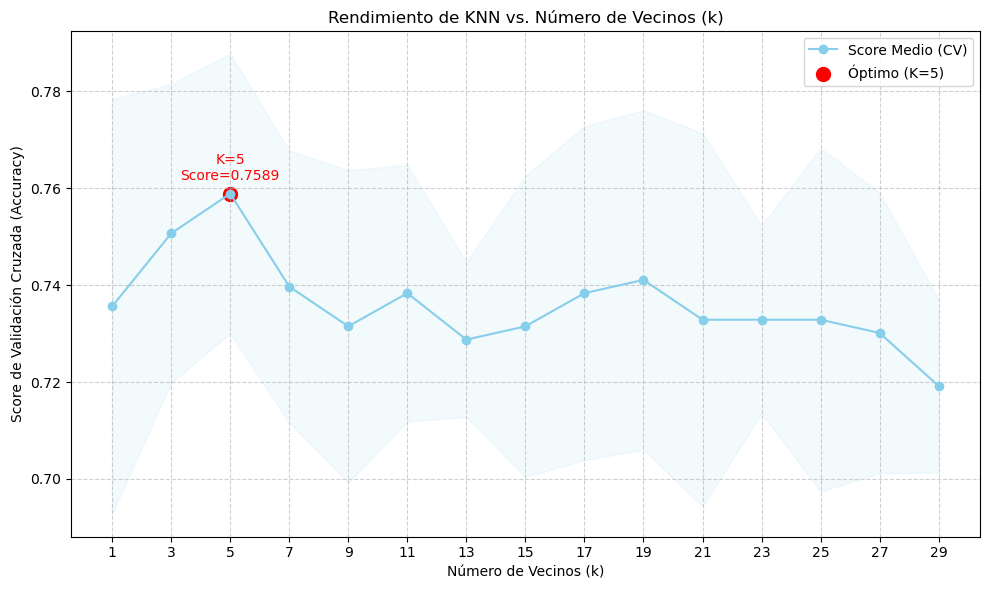


DataFrame de resultados de la optimización:
|   n_neighbours |   score_medio |   score_std |
|---------------:|--------------:|------------:|
|              1 |      0.735616 |   0.0427959 |
|              3 |      0.750685 |   0.0308143 |
|              5 |      0.758904 |   0.0288648 |
|              7 |      0.739726 |   0.0280738 |
|              9 |      0.731507 |   0.0322427 |
|             11 |      0.738356 |   0.0264919 |
|             13 |      0.728767 |   0.0159752 |
|             15 |      0.731507 |   0.0310569 |
|             17 |      0.738356 |   0.0344923 |
|             19 |      0.741096 |   0.0350321 |


In [ ]:
# KNN
# 1. SETUP: Cargar Data y Definir Feature Set
df = pd.read_csv("dataset.csv")

# Codificar target a binario
le = LabelEncoder()
y_encoded = le.fit_transform(df["clinical"])

# Definir Feature Set (Excluyendo AMscore)
X_shared = df.drop(columns=["alpha_missense_score", "clinical"])

# Definir las columnas para el preprocesador
categorical_features = X_shared.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_shared.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Definir el Preprocesador (Scaling + One-Hot)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# 2. FUNCIÓN ADAPTADA PARA OPTIMIZACIÓN (KNN Pipeline)

def scores_knn_optimized(X, y, start, stop, step, preprocessor):
    
    scores_para_df = []
    # Usamos StratifiedKFold para mantener el balance de clases en cada fold
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for i in range(start, stop, step):
        
        # Instanciamos el Pipeline completo, incluyendo el nuevo valor de n_neighbors
        model_pipeline = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("knn", KNeighborsClassifier(n_neighbors=i))
        ])

        # cross_val_score evalúa el rendimiento del Pipeline completo
        cv_scores = cross_val_score(model_pipeline, X, y, cv=kf, scoring='accuracy', n_jobs=-1)

        # Calculamos la media y el desvío de los scores de CV
        dict_row_score = {
            'score_medio': np.mean(cv_scores),
            'score_std': np.std(cv_scores),
            'n_neighbours': i
        }
        scores_para_df.append(dict_row_score)
    
    df_scores = pd.DataFrame(scores_para_df)
    
    # Incorporamos los límites inferior y superior para la gráfica de error
    df_scores['limite_inferior'] = df_scores['score_medio'] - df_scores['score_std']
    df_scores['limite_superior'] = df_scores['score_medio'] + df_scores['score_std']
    
    return df_scores

# 3. EJECUCIÓN Y VISUALIZACIÓN

# Definir el rango de K a buscar
k_start = 1
k_stop = 30
k_step = 2

# Ejecutar la función de optimización con el set de features sin AMscore
df_scores = scores_knn_optimized(X_shared, y_encoded, k_start, k_stop, k_step, preprocessor)

# --- Identificar el K óptimo ---
k_optimo = df_scores.loc[df_scores['score_medio'].idxmax(), 'n_neighbours']
score_optimo = df_scores['score_medio'].max()

print("="*60)
print(f"ANÁLISIS DE OPTIMIZACIÓN KNN (Excluyendo AMscore)")
print(f"K Óptimo (Mayor Score Medio): k = {k_optimo}")
print(f"Score de Validación Medio en K={k_optimo}: {score_optimo:.4f}")
print("="*60)

# --- Graficación de Resultados ---
plt.figure(figsize=(10, 6))

# Curva de rendimiento (score_medio) con barra de error (score_std)
plt.plot(df_scores['n_neighbours'], df_scores['score_medio'], marker='o', color='skyblue', label='Score Medio (CV)')
plt.fill_between(df_scores['n_neighbours'], df_scores['limite_inferior'], df_scores['limite_superior'], color='skyblue', alpha=0.1)

# Marcar el punto óptimo
plt.scatter(k_optimo, score_optimo, color='red', s=100, label=f'Óptimo (K={k_optimo})')
plt.annotate(f'K={k_optimo}\nScore={score_optimo:.4f}', (k_optimo, score_optimo), 
             textcoords="offset points", xytext=(0,10), ha='center', color='red', fontsize=10)

plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Score de Validación Cruzada (Accuracy)')
plt.title('Rendimiento de KNN vs. Número de Vecinos (k)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(k_start, k_stop, k_step))
plt.tight_layout()
plt.show()

# Guardar DataFrame para posible análisis posterior
print("\nDataFrame de resultados de la optimización:")
print(df_scores[['n_neighbours', 'score_medio', 'score_std']].head(10).to_markdown(index=False))

### Conclusiones KNN

**K Óptimo:** El número de vecinos que maximiza el score de validación cruzada es $\mathbf{K=5}$, alcanzando un score medio de $0.7589$.

**Punto de Overfitting/Mala Generalización:** El modelo comienza a generalizar peor a partir de $K=7$. Para valores bajos de $K$ (como $K=1$), el modelo es demasiado sensible a puntos de datos individuales (alta varianza), pero a partir de $K=7$, el aumento de vecinos suaviza demasiado la frontera de decisión, resultando en una pérdida de precisión sobre los datos de validación .

**Rendimiento:** Este score ($0.7589$) es ligeramente inferior al Accuracy de $0.76$ que se obtuvo en la evaluación previa con $K=5$, lo cual es normal ya que el CV usa una estrategia de folds más estricta para la evaluación.

**Comparación con Sobreajuste:** El valor de $K=5$ sigue siendo el punto de mejor generalización para este set de features (sin AMscore), confirmando que el valor por defecto ($K=5$) es el más robusto para los datos, aunque con un margen de mejora en la estabilidad de las predicciones (el desvío estándar es bajo, $\pm 0.0289$).

Matriz de Scores de Validación Cruzada por n_estimators (T):
|   score_medio |   score_std |   n_estimators |   limite_inferior |   limite_superior |
|--------------:|------------:|---------------:|------------------:|------------------:|
|        0.7342 |      0.0379 |        10.0000 |            0.6964 |            0.7721 |
|        0.7616 |      0.0381 |        20.0000 |            0.7235 |            0.7998 |
|        0.7671 |      0.0349 |        30.0000 |            0.7322 |            0.8020 |
|        0.7630 |      0.0308 |        40.0000 |            0.7322 |            0.7938 |
|        0.7548 |      0.0325 |        50.0000 |            0.7223 |            0.7873 |
|        0.7658 |      0.0391 |        60.0000 |            0.7267 |            0.8048 |
|        0.7658 |      0.0320 |        70.0000 |            0.7338 |            0.7977 |
|        0.7671 |      0.0341 |        80.0000 |            0.7330 |            0.8012 |
|        0.7726 |      0.0342 |        90.0000 | 

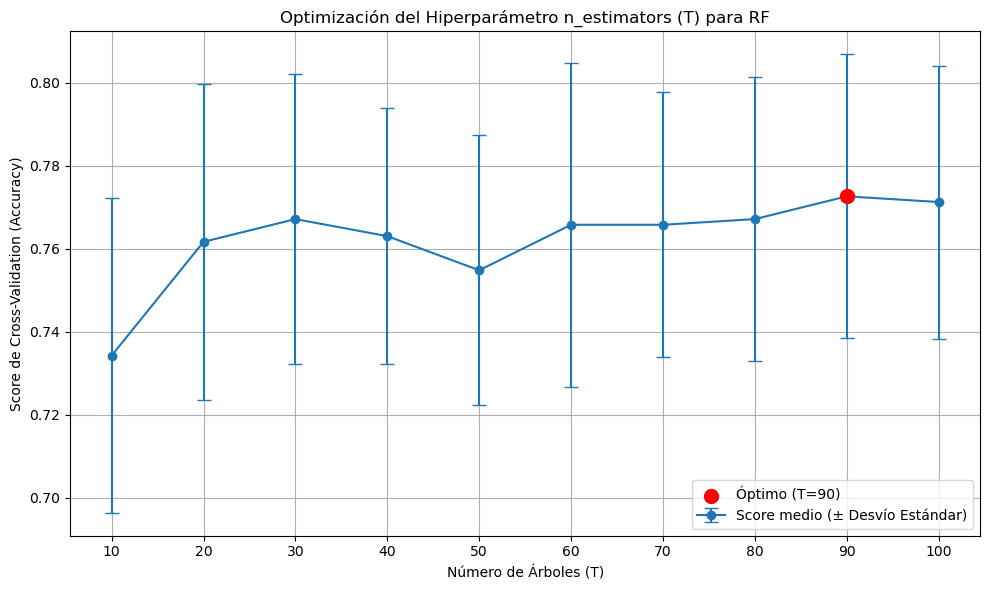

In [15]:
#Random Forest
# --- 1. Carga de datos y Preparación ---
df = pd.read_csv("dataset.csv")
# Codificar el target (ya asumido en y_encoded = le.fit_transform(df["clinical"]))
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df["clinical"])

# --- Definición de Feature Set (AMscore EXCLUIDO) ---
X_no_amscore = df.drop(columns=["alpha_missense_score", "clinical"])
X_rf_encoded = pd.get_dummies(X_no_amscore, drop_first=True)

# Definir la estrategia de Validación Cruzada (CV)
# Usamos StratifiedKFold para manejar el desbalance de clases
kf_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. FUNCIÓN ADAPTADA PARA OPTIMIZACIÓN (scores_rf)

def scores_rf(X, y, cv_strategy, start, stop, step):
    
    scores_para_df = []
    
    # Rango de n_estimators (T) a evaluar
    for i in range(start, stop, step):
        
        # Instanciar el modelo con el número variable de árboles (i)
        model = RandomForestClassifier(
            n_estimators=i, 
            random_state=42, 
            class_weight='balanced'
        )

        # cross_val_score evalúa el modelo
        cv_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy')

        # Crear el diccionario con la media y el desvío
        dict_row_score = {
            'score_medio': np.mean(cv_scores),
            'score_std': np.std(cv_scores),
            'n_estimators': i
        }

        scores_para_df.append(dict_row_score)
    
    # Crear el DataFrame de resultados
    df_scores = pd.DataFrame(scores_para_df)
    
    # Incorporar límites de desvío
    df_scores['limite_inferior'] = df_scores['score_medio'] - df_scores['score_std']
    df_scores['limite_superior'] = df_scores['score_medio'] + df_scores['score_std']
    
    return df_scores

# 3. EJECUCIÓN Y VISUALIZACIÓN DE LA OPTIMIZACIÓN

# Rango de T a evaluar (de 10 a 110, paso 10)
T_START = 10
T_STOP = 110
T_STEP = 10

# Ejecutar la función de optimización con el set de features sin AMscore
df_scores_rf = scores_rf(X_rf_encoded, y_encoded, kf_strategy, T_START, T_STOP, T_STEP)

print("Matriz de Scores de Validación Cruzada por n_estimators (T):")
print(df_scores_rf.to_markdown(index=False, floatfmt=".4f"))

# Identificar el T óptimo (máximo score_medio)
t_optimo = df_scores_rf.loc[df_scores_rf['score_medio'].idxmax(), 'n_estimators']
score_maximo = df_scores_rf['score_medio'].max()

print(f"\nEl valor óptimo de n_estimators es T = {t_optimo} (Score medio: {score_maximo:.4f})")

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.errorbar(df_scores_rf['n_estimators'], df_scores_rf['score_medio'], 
             yerr=df_scores_rf['score_std'], fmt='-o', capsize=5, 
             label='Score medio (± Desvío Estándar)')

# Marcar el punto óptimo
plt.scatter(t_optimo, score_maximo, color='red', s=100, label=f'Óptimo (T={t_optimo})', zorder=5)

plt.title('Optimización del Hiperparámetro n_estimators (T) para RF')
plt.xlabel('Número de Árboles (T)')
plt.ylabel('Score de Cross-Validation (Accuracy)')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(T_START, T_STOP, T_STEP))
plt.tight_layout()
plt.show()

### Optimización de RF mediante GridSearch

La pérdida de rendimiento en RF (el gran Gap de $0.213$) no provino de la optimización de $T$, sino del alto sobreajuste de la profundidad de cada árbol (max_depth), un hiperparámetro que en el código se usó por defecto (lo que permite árboles muy profundos que memorizan los datos de entrenamiento). Esto significa que los árboles individuales son demasiado complejos y están memorizando el ruido y los detalles específicos de los datos de entrenamiento.

Para mejorar esto, se limitó la complejidad del modelo (regularización) y se aseguró un ensamblaje (Random Forest) más estable.

Estrategias utilizadas: encontrar el valor óptimo de max_depth y min_samples_leaf mientras se mantiene un número suficiente de árboles (n_estimators) para la estabilidad (T optimo = 90).

In [18]:
# --- 1. Carga de datos y Preparación ---
df = pd.read_csv("dataset.csv")

# Codificar el target a binario (0/1)
le = LabelEncoder()
y_encoded = le.fit_transform(df["clinical"])

# --- Definición de Feature Set (AMscore EXCLUIDO) ---
X_no_amscore = df.drop(columns=["alpha_missense_score", "clinical"])
X_rf_encoded = pd.get_dummies(X_no_amscore, drop_first=True)

# Definir la estrategia de Validación Cruzada (CV)
# Usamos StratifiedKFold para manejar el desbalance de clases
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. OPTIMIZACIÓN DE max_depth y min_samples_leaf (GridSearch)

# 2.1. Definir el modelo base (T=90 para estabilidad)
rf_model_base = RandomForestClassifier(
    n_estimators=90,  # Usamos el T óptimo encontrado
    random_state=42,
    class_weight='balanced'
)

# 2.2. Definir la grilla de hiperparámetros (Parámetros de regularización)
param_grid = {
    'max_depth': [3, 5, 8, 10, 15],  # Límites la complejidad
    'min_samples_leaf': [1, 3, 5, 10]  # Controla la granularidad
}

# 2.3. Ejecutar Grid Search
# Optimizamos por 'roc_auc' ya que es la métrica más robusta para desbalance
grid_search = GridSearchCV(
    estimator=rf_model_base,
    param_grid=param_grid,
    scoring='roc_auc', 
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_rf_encoded, y_encoded)

# 3. ANÁLISIS DE RESULTADOS

# Obtener los mejores parámetros y score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Crear DataFrame de resultados para visualizar
df_results = pd.DataFrame(grid_search.cv_results_)
df_results = df_results[['param_max_depth', 'param_min_samples_leaf', 'mean_test_score', 'std_test_score']]
df_results.columns = ['max_depth', 'min_samples_leaf', 'mean_auc_cv', 'std_auc_cv']

print("\n" + "="*50)
print("             Resultados de Grid Search (AUC)")
print("="*50)
print(df_results.to_markdown(index=False, floatfmt=".4f"))

print("\n" + "="*50)
print("            Parámetros Óptimos Encontrados")
print("="*50)
print(f"Mejor ROC AUC (CV): {best_score:.4f}")
print(f"Mejores Parámetros: {best_params}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

             Resultados de Grid Search (AUC)
|   max_depth |   min_samples_leaf |   mean_auc_cv |   std_auc_cv |
|------------:|-------------------:|--------------:|-------------:|
|      3.0000 |             1.0000 |        0.7805 |       0.0275 |
|      3.0000 |             3.0000 |        0.7786 |       0.0254 |
|      3.0000 |             5.0000 |        0.7812 |       0.0248 |
|      3.0000 |            10.0000 |        0.7794 |       0.0230 |
|      5.0000 |             1.0000 |        0.7800 |       0.0356 |
|      5.0000 |             3.0000 |        0.7802 |       0.0264 |
|      5.0000 |             5.0000 |        0.7834 |       0.0271 |
|      5.0000 |            10.0000 |        0.7749 |       0.0235 |
|      8.0000 |             1.0000 |        0.7962 |       0.0387 |
|      8.0000 |             3.0000 |        0.7825 |       0.0279 |
|      8.0000 |             5.0000 |        0.7858 |       0.0301 |
|      8

**Análisis del Sobreajuste Potencial**

Los parámetros óptimos encontrados indican una alta complejidad y, por lo tanto, un alto riesgo de sobreajuste:
- max_depth: 15. Este valor representa la máxima profundidad probada en la grilla y es la que mayor ganancia de score ofreció. Esto significa que el modelo necesita árboles profundos para capturar las relaciones complejas en tus features.
- min_samples_leaf: 1. Este valor es la mínima regularización posible. Al permitir que las hojas tengan un solo punto de dato, se maximiza el ajuste (fit) en los datos de entrenamiento.

Conclusión y Riesgo
La combinación ganadora (max_depth=15, min_samples_leaf=1) es la menos restringida en la grilla. Si bien maximiza el $\text{AUC}_{\text{CV}}$, es extremadamente susceptible al sobreajuste.

Riesgo: El modelo probablemente exhibirá un Gap (sobreajuste) muy grande cuando se compare su $\text{AUC}_{\text{Train}}$ con su $\text{AUC}_{\text{CV}}$, similar o peor al que viste anteriormente ($\approx 0.225$), porque los árboles son muy complejos y pueden alcanzar el $\text{AUC}_{\text{Train}} \approx 1.0$.

Para mitigar este riesgo, se podría:
- Aceptar los parámetros que dan un $\text{AUC}_{\text{CV}}$ ligeramente menor pero un $\text{std}_{\text{auc}}$ (desvío estándar) mucho más bajo (indicando mayor estabilidad). Por ejemplo, max_depth=8 o 10 con min_samples_leaf=3 son más seguros.
- Mantener $\text{max\_depth}=15$ pero aumentar min_samples_leaf a 3 o 5 para forzar un poco de regularización y evitar que las hojas se centren en el ruido.

### Conclusiones RF

**Parámetro Óptimo:** Para el modelo Random Forest (sin AMscore), el valor más robusto es utilizar $90$ árboles, lo que proporciona el mejor equilibrio entre rendimiento y estabilidad ($\text{Score Medio}=0.7726$).

**Punto de Overfitting/Diminishing Returns:** Para $T$ (número de árboles), la complejidad del modelo se estabiliza. El modelo alcanza su capacidad predictiva máxima en $T=90$. Para valores mayores (como $T=100$), el score comienza a declinar ligeramente. En este contexto, el modelo ya no gana más rendimiento a partir de $\mathbf{T=90}$, solo aumenta el tiempo de cómputo sin mejorar la capacidad de generalización.

**Rendimiento Base:** Este score óptimo ($0.7726$) es ligeramente superior al Accuracy de $0.73$ que se obtuvo con $T=10$ árboles en el reporte de CV anterior.

**Rendimiento aplicando GridSearch** El $\text{AUC}_{\text{CV}}$ mejoró significativamente de $0.760$ (modelo base) a $\mathbf{0.809}$ (modelo optimizado), lo que confirma que el modelo inicial estaba subparametrizado.


### **Refinamiento de los modelos KNN y RF:** Se recomienda utilizar ahora un $\mathbf{K=5}$ para KNN y $\mathbf{T=90}$ para Random Forest en cualquier análisis comparativo futuro.